In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(1000, 1) * 10  # Feature
y = X[:, 0]**2 + np.random.normal(0, 3, size=1000)  # Quadratic function with noise

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Initialize and train the model
gb_regressor = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb_regressor.fit(X_train, y_train)


GradientBoostingRegressor(n_estimators=200, random_state=42)

In [8]:
# Predictions
y_pred_train = gb_regressor.predict(X_train)
y_pred_test = gb_regressor.predict(X_test)


In [10]:
# Compute errors
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Print evaluation metrics
print(f"Train MSE: {train_mse:.2f}, Train R²: {train_r2:.2f}")
print(f"Test MSE: {test_mse:.2f}, Test R²: {test_r2:.2f}")


Train MSE: 5.16, Train R²: 0.99
Test MSE: 9.89, Test R²: 0.99


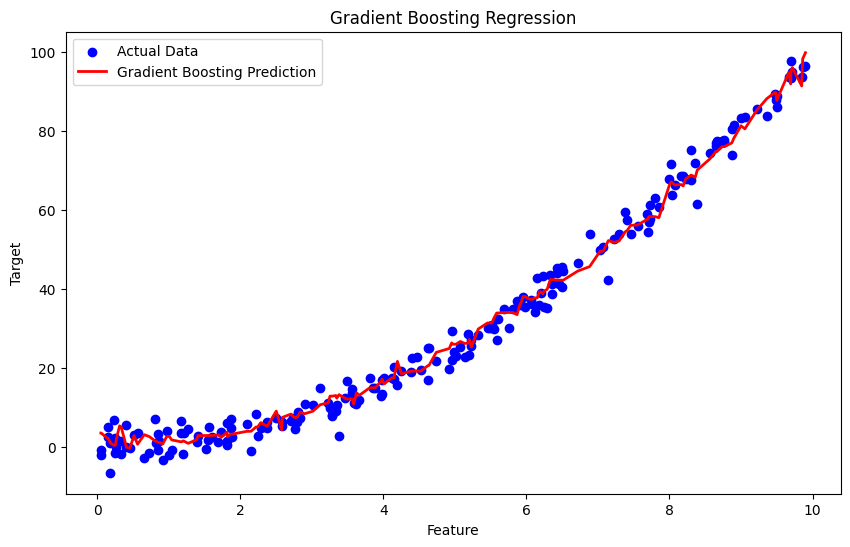

In [11]:
# Sort values for better visualization
X_test_sorted = np.sort(X_test, axis=0)
y_test_pred_sorted = gb_regressor.predict(X_test_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test_sorted, y_test_pred_sorted, color="red", label="Gradient Boosting Prediction", linewidth=2)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Gradient Boosting Regression")
plt.legend()
plt.show()
